### Practical Work

1. Train a RF on TF-8Bind data. 
2. Predict new sequences with SMW from seed sequence
3. Score unique unssen predicted sequences
4. best sequence == new seed
5. plot how good prediciton is against real world labels


In [1]:
# Imports
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# LSTM model^
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

SEED = 42

2026-01-05 12:56:29.283671: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/meier/Documents/PracticalWork/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


### Prepare Dataset: 
Der Trainingssatz, der den Offline-MBO-Algorithmen zur Verfügung gestellt wird, ist auf die unteren 50 % beschränkt, was zu einem sichtbaren Trainingssatz von 32898 Proben führt.

In [43]:
# Load data and create train-test-split, one-hot encode sequences
df = pd.read_csv('tf_bind_8-SIX6_REF_R1/dataset.csv')

# sort dataframe by binding scores
#df = df.sort_values(by='binding_scores').reset_index(drop=True)


# select 50% of data with lowest binding scores for training
train_size = int(0.5 * len(df))
train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

# remix training data
train_df = train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
print(train_df.head())

x = train_df.iloc[:, :-2].values
y = train_df.iloc[:, -1].values
print(f'Training samples: {x.shape[0]}')

# one hot encode sequences
x = tf.one_hot(x, depth=4)
x = x.numpy()  # Convert to numpy for train_test_split compatibility

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=SEED)
print(f'One-hot encoded shape: {x_train.shape}')

   0  1  2  3  4  5  6  7  sequence  binding_scores
0  2  3  1  1  3  2  0  0  GTCCTGAA        0.409743
1  1  2  1  1  2  3  0  1  CGCCGTAC        0.354018
2  2  0  2  3  2  2  0  0  GAGTGGAA        0.378273
3  1  1  3  1  2  0  2  2  CCTCGAGG        0.686008
4  2  0  2  1  1  2  1  0  GAGCCGCA        0.243619
Training samples: 32896
One-hot encoded shape: (26316, 8, 4)


In [12]:
x = df.iloc[:, :-2].values
# one hot encode the sequences
x_tensor = tf.one_hot(x, depth=4)
x = x_tensor.numpy()
print(f'One-hot encoded shape full data: {x.shape}')
y = df.iloc[:, -1].values



print(f'Training samples: {x_train.shape[0]}')
print(f'Testing samples: {x_test.shape[0]}')

One-hot encoded shape full data: (65792, 8, 4)
Training samples: 32896
Testing samples: 32896


In [44]:
# create dataframe for lookup task
df_oracle = test_df[['0', '1', '2', '3', '4', '5', '6', '7', 'binding_scores']]
x_oracle = df_oracle.iloc[:, :-1].values
df_oracle['one_hot_seq'] = [tf.one_hot(seq, depth=4).numpy().flatten() for seq in x_oracle]
df_oracle.drop(columns=df_oracle.columns[:-2], inplace=True)
df_oracle.head(10)

,binding_scores,one_hot_seq
32896,0.524749,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."
32897,0.366511,"[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."
32898,0.446759,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."
32899,0.455201,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."
32900,0.512627,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, ..."
32901,0.526110,"[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, ..."
32902,0.431194,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, ..."
32903,0.445007,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, ..."
32904,0.509081,"[0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, ..."
32905,0.343442,"[0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ..."


In [45]:
def oracle_lookup(one_hot_sequence):
    """Looks up the real binding score for a given one-hot encoded sequence."""
    flattened_seq = one_hot_sequence.flatten()
    match = df_oracle[df_oracle['one_hot_seq'].apply(lambda x: np.array_equal(x, flattened_seq))]
    if not match.empty:
        return match['binding_scores'].values[0]
    else:
        return 0.0  # no score if not found

In [46]:
rf = RandomForestRegressor(n_estimators=50, random_state = SEED)

# flatten training data
flat_shape = x_train.shape[1] * x_train.shape[2]
x_reshaped = x_train.reshape(x_train.shape[0], flat_shape)

rf.fit(x_reshaped, y_train)

# Evaluation just on a few samples from test set
x_test = x_test[:100]
y_test = y_test[:100]
x_test = x_test.reshape(x_test.shape[0], flat_shape)

y_prediction = rf.predict(x_test)
r2 = r2_score(y_test, y_prediction)
mse = mean_squared_error(y_test, y_prediction)

print(f'R2 Score: {r2}; MSE: {mse}')

R2 Score: 0.5860845063971984; MSE: 0.011878253094691225


In [47]:
import numpy as np
import tensorflow as tf

class SMW:

    def __init__(self, nucleotides):
        self.nucleotides = nucleotides
        self.n = len(nucleotides)

    def one_hot_encode(self, sequence):
        sequence_tensor = tf.one_hot(
            sequence, depth=4
        )
        sequence_numpy = sequence_tensor.numpy() 
        shape = sequence_numpy.shape[0] * sequence_numpy.shape[1]
        sequence_n_flat = sequence_numpy.reshape(1, shape)
        return sequence_n_flat

    def mutate_sequence(self, sequence, pos):
        sequence = list(sequence)
        if pos is None:
            pos = np.random.randint(0, len(sequence))
        # Get current nucleotide and possible mutations, make sure that nuc is different
        current_nucleotide = sequence[pos]
        possible_mutations = [nuc for nuc in self.nucleotides if nuc !=
                                current_nucleotide]
        # Replace nucleotide at position 
        new_nucleotide = np.random.choice(possible_mutations)
        sequence[pos] = new_nucleotide
        return sequence
        
    def walk(self, start_sequence, n_steps):
        current_seq = start_sequence
        history = []
        for step in range(n_steps):
            mutant = self.mutate_sequence(current_seq, None)
            mutant_one_hot = self.one_hot_encode(mutant)
            #mutant_fitness = fitness_function(mutant_one_hot)

            # Check if mutant is better than current
            # Yes: move to mutant
            #if mutant_fitness > current_fitness:
            current_seq = mutant
            #    current_fitness = mutant_fitness

            history.append(mutant_one_hot)
        return history


In [109]:
#Lstm model for sequence generation
model = Sequential()
model.add(LSTM(100, input_shape = (x.shape[1:])))
model.add(Dense(4, activation='softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.load_weights('lstm_sequence_model.h5')

model.summary()

def generate_sequence(seed_sequence, next_chars, max_sequence_len):
    for _ in range(next_chars):
        token_list = tf.one_hot(seed_sequence, depth=4)
        token_list = tf.reshape(token_list, (1, token_list.shape[0], token_list.shape[1]))
        predicted = model.predict(token_list, verbose=0)
        predicted_char = tf.argmax(predicted, axis=1).numpy()[0]
        seed_sequence.append(predicted_char)
        if len(seed_sequence) > max_sequence_len:
            seed_sequence = seed_sequence[1:]
    return seed_sequence

def generate_mutations(seed_sequence, n_mutations):
    mutations = []
    seed_sequence = seed_sequence[-1]
    for _ in range(n_mutations):
        mutated_sequence = generate_sequence(seed_sequence.copy(), next_chars=1, max_sequence_len=len(seed_sequence))
        mutations.append(mutated_sequence)
        seed_sequence = mutated_sequence[-1] # update seed to last generated character
    return mutations


/Users/meier/Documents/PracticalWork/.venv/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 100)            │        42,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           404 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,404 (165.64 KB)

 Trainable params: 42,404 (165.64 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
## Main Loop
n_steps = 20
mutation_steps = 100
use_SMW = True

seed_sequence = tf.argmax(x_train[1300], axis=1).numpy().tolist()
if use_SMW: 
    # Start from a seed sequence in the training data (convert one-hot to integer indices)
    smw = SMW(nucleotides=[0, 1, 2, 3])


# Flatten x_train for comparison
x_train_flat = x_train.reshape(x_train.shape[0], flat_shape)

df_all_values = pd.DataFrame({'mutation': [], 'predicted_score': [], 'real_score': [], 'error': []})

def calculate_error(predicted_scores, real_scores):
    errors = []
    for pred, real in zip(predicted_scores, real_scores):
        error = abs(pred - real)
        errors.append(error)
    return errors

score_prev = -1
seen_sequences = x_train_flat

for i in range(n_steps):
    values = {'mutation': [], 'predicted_score': []}
    if not use_SMW:
        mutations = generate_mutations(seed_sequence, mutation_steps)
        # one-hot encode mutations
        mutations = [tf.one_hot(mut, depth=4).numpy().reshape(1, flat_shape) for mut in mutations]
    else: 
        mutations = smw.walk(seed_sequence, mutation_steps)

    # check if mutations are in train data
    for idx, mut in enumerate(mutations):
        # Check if mutation is NOT in training data
        is_in_train = np.any(np.all(seen_sequences == mut, axis=1))
        if not is_in_train:
            # If not in training data, add to list
            mutations_score = rf.predict(mut)
            values['mutation'].append(mut)
            values['predicted_score'].append(mutations_score[0])
        
    
    # Select best mutation -> highest value
    # sort values by predicted score -> highest score first
    values_df = pd.DataFrame(values)
    values_df_sorted = values_df.sort_values(by='predicted_score', ascending=False)
    # keep only top 1
    values_df_sorted = values_df_sorted.head(1)
    # append to all values dataframe for later analysis
    df_all_values = pd.concat([df_all_values, values_df_sorted], ignore_index=True)

    # update seed sequence to best mutation -> highes predicted score
    if len(values_df_sorted) == 0:
        print(f'Step {i+1}/{n_steps}, No new mutations found.')
        continue

    # update seed sequence only if score is higher than previous best
    value_new =values_df_sorted.iloc[0]["predicted_score"]
    if value_new > score_prev:
        score_prev = value_new
        seed_sequence_one_hot = values_df_sorted.iloc[0]['mutation']
        seed_sequence = tf.argmax(tf.reshape(seed_sequence_one_hot, (seed_sequence_one_hot.shape[1]//4, 4)), axis=1).numpy().tolist()
        print(f'Step {i+1}/{n_steps}, Best predicted score: {values_df_sorted.iloc[0]["predicted_score"]}')
    else:
        print(f'Step {i+1}/{n_steps}, No better mutation found. Keeping previous seed sequence.')    
    
    # make shure not to check seen sequences again
    if len(values['mutation']) > 0:
        new_mutations = np.vstack(values['mutation'])
        seen_sequences = np.vstack([seen_sequences, new_mutations])
    print(f'New seed sequence: {seed_sequence}')


Step 1/20, Best predicted score: 0.7996153038000001
New seed sequence: [3, 2, 3, 0, 3, 1, 2, 3]
Step 2/20, Best predicted score: 0.9467546180000003
New seed sequence: [3, 1, 2, 2, 3, 0, 3, 1]
Step 3/20, Best predicted score: 0.9660118216
New seed sequence: [3, 2, 2, 2, 3, 0, 3, 1]
Step 4/20, No better mutation found. Keeping previous seed sequence.
New seed sequence: [3, 2, 2, 2, 3, 0, 3, 1]
Step 5/20, Best predicted score: 0.9712707736000002
New seed sequence: [3, 2, 2, 0, 3, 0, 3, 1]
Step 6/20, No better mutation found. Keeping previous seed sequence.
New seed sequence: [3, 2, 2, 0, 3, 0, 3, 1]
Step 7/20, No better mutation found. Keeping previous seed sequence.
New seed sequence: [3, 2, 2, 0, 3, 0, 3, 1]
Step 8/20, No better mutation found. Keeping previous seed sequence.
New seed sequence: [3, 2, 2, 0, 3, 0, 3, 1]
Step 9/20, No better mutation found. Keeping previous seed sequence.
New seed sequence: [3, 2, 2, 0, 3, 0, 3, 1]
Step 10/20, No better mutation found. Keeping previous se

In [55]:
#lookup real scores and calculate error
for index, row in df_all_values.iterrows():
    real_score = oracle_lookup(row['mutation'])
    df_all_values.at[index, 'real_score'] = real_score
    error = abs(row['predicted_score'] - real_score)
    df_all_values.at[index, 'error'] = error

print(df_all_values.head(10))

                                            mutation  predicted_score  \
0  [[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0,...         0.799615   
1  [[0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0,...         0.946755   
2  [[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0,...         0.966012   
3  [[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0,...         0.872166   
4  [[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0,...         0.971271   
5  [[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0,...         0.922883   
6  [[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0,...         0.901867   
7  [[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0,...         0.823225   
8  [[0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0,...         0.786107   
9  [[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0,...         0.728956   

   real_score     error  
0    0.911155  0.111540  
1    0.852771  0.093984  
2    0.944450  0.021562  
3    0.874933  0.002767  
4    0.962324  0.008947  
5    0.993506  0.070623  
6    0.858347 

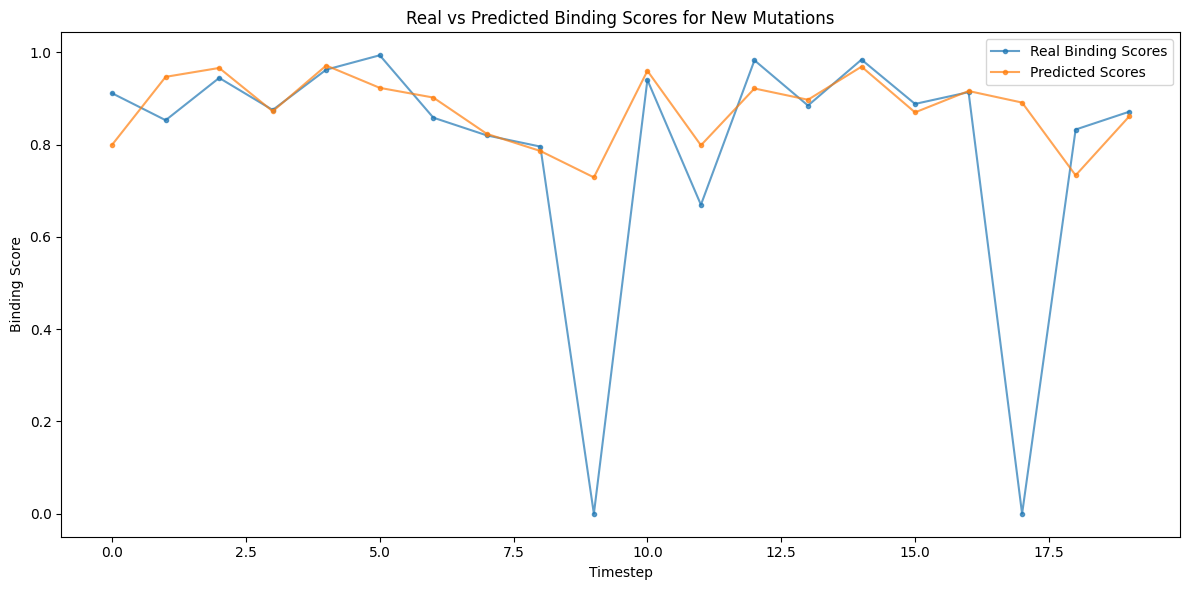

In [56]:
import matplotlib.pyplot as plt


real_scores = df_all_values['real_score']
predicted_scores = df_all_values['predicted_score']
# Plot real vs predicted scores
plt.figure(figsize=(12, 6))
# Downsample to every 10th point for better visibility
step = 1
indices = range(0, len(real_scores), step)
real_scores_sampled = real_scores.iloc[::step]
predicted_scores_sampled = predicted_scores.iloc[::step]
plt.plot(range(len(real_scores_sampled)), real_scores_sampled, label='Real Binding Scores', alpha=0.7, marker='o', markersize=3)
plt.plot(range(len(predicted_scores_sampled)), predicted_scores_sampled, label='Predicted Scores', alpha=0.7, marker='o', markersize=3)
plt.xlabel('Timestep')
plt.ylabel('Binding Score')
plt.title('Real vs Predicted Binding Scores for New Mutations')
plt.legend()
plt.tight_layout()
plt.show()

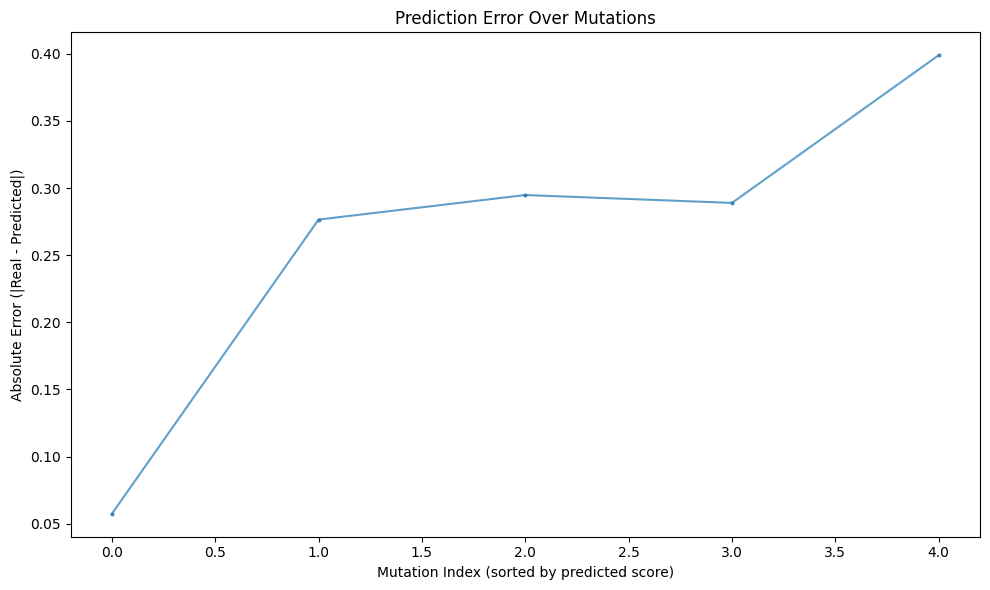

In [35]:
# Calculate absolute error for each mutation
errors = [abs(real - pred) for real, pred in zip(real_scores, predicted_scores)]

# Plot error over mutation index
plt.figure(figsize=(10, 6))
plt.plot(range(len(errors)), errors, marker='o', markersize=2, alpha=0.7)
plt.xlabel('Mutation Index (sorted by predicted score)')
plt.ylabel('Absolute Error (|Real - Predicted|)')
plt.title('Prediction Error Over Mutations')
plt.tight_layout()
plt.show()

# Also plot a rolling average to see the trend more clearly
window_size = 20
if len(errors) >= window_size:
    rolling_errors = pd.Series(errors).rolling(window=window_size).mean()
    plt.figure(figsize=(10, 6))
    plt.plot(range(len(errors)), errors, alpha=0.3, label='Individual Errors')
    plt.plot(range(len(rolling_errors)), rolling_errors, color='red', linewidth=2, label=f'Rolling Average (window={window_size})')
    plt.xlabel('Mutation Index (sorted by predicted score)')
    plt.ylabel('Absolute Error')
    plt.title('Prediction Error with Rolling Average')
    plt.legend()
    plt.tight_layout()
    plt.show()